Epoch 1/100


/Users/vroni/miniconda3/envs/ParkData/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100


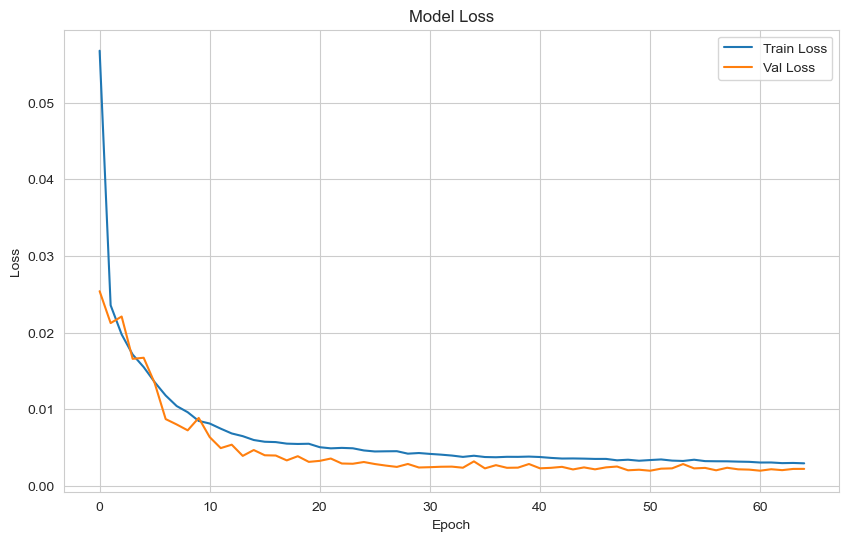

100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 398ms/step
(3199, 1)
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 279ms/step
Train Score: 20.58 RMSE
Test Score: 26.24 RMSE


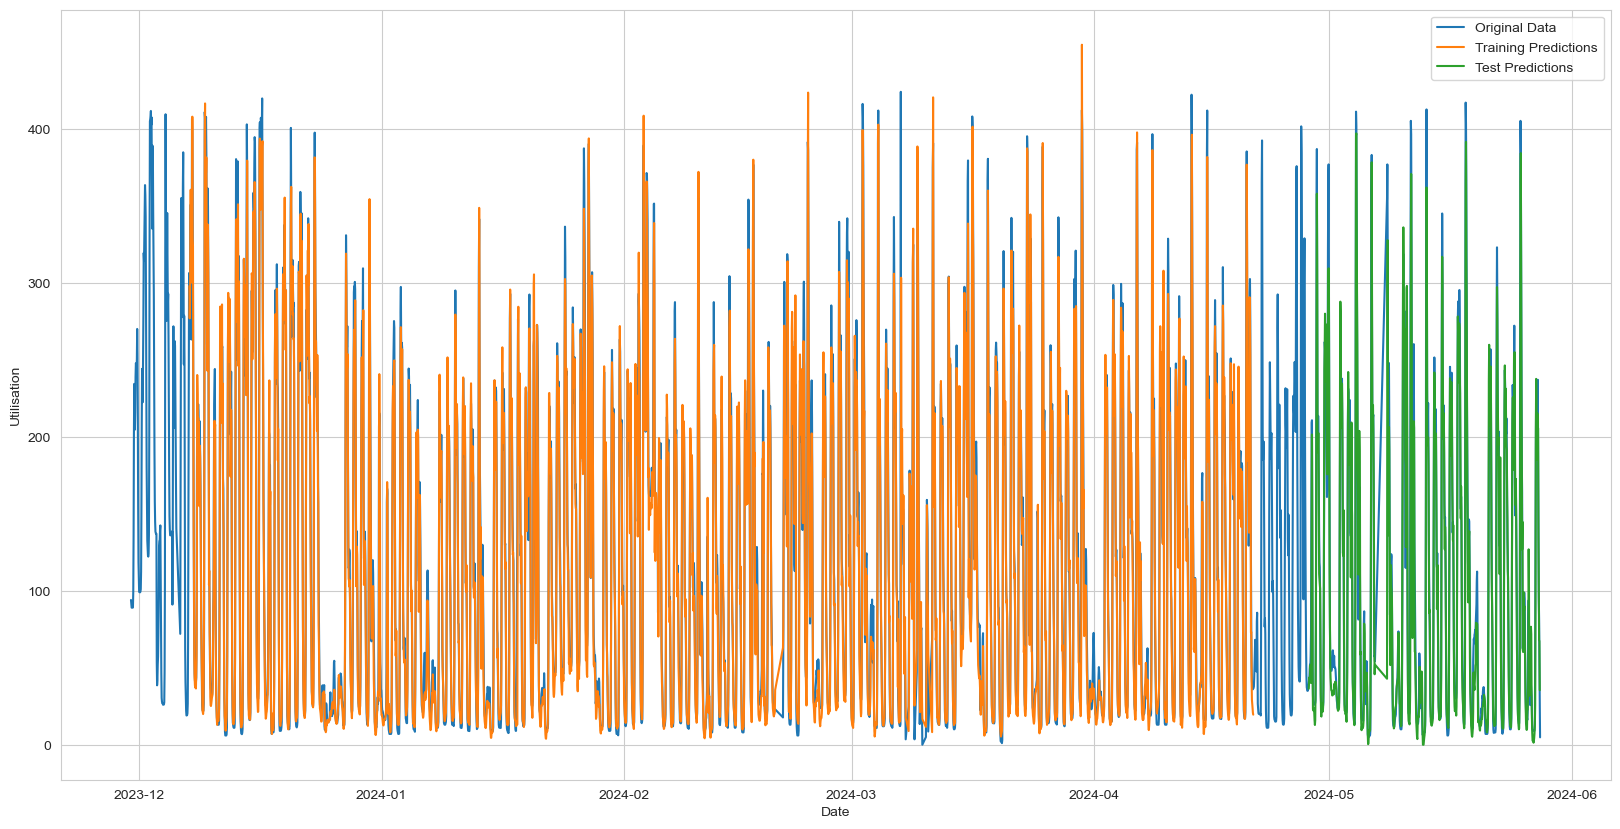

In [12]:
from keras.src.callbacks import EarlyStopping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers import Adam
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# convert an array of values into a dataset matrix
def create_dataset(dataset, window=168):
	dataX = []
	dataY = []
	for i in range(len(dataset)-window-1):
		dataX.append(dataset[i:(i+window), :])
		dataY.append(dataset[i + window, 0])
	return np.array(dataX), np.array(dataY)

tf.random.set_seed(7)
data = pd.read_csv('./data/out_hourly.csv')
dataset = pd.DataFrame(data)
dataset = dataset.sort_values('timestamp')
dataset['timestamp'] = pd.to_datetime(dataset['timestamp'])
start_date = pd.to_datetime('2023-11-30')
end_date = pd.to_datetime('2024-05-28')
dataset = dataset[(dataset['timestamp'] >= start_date) & (dataset['timestamp'] <= end_date)]
dataset['hour'] = dataset['timestamp'].dt.hour
dataset['dayOfWeek'] = dataset['timestamp'].dt.dayofweek
dataset['event_name'] = dataset['event_name'].apply(lambda x: 1 if isinstance(x, str) and x != "0" else 0)
dataset['holiday'] = dataset['holiday'].apply(lambda x: 1 if pd.notna(x) and isinstance(x, str) and x.strip() != "" else 0)

dataset.set_index('timestamp', inplace=True)
dates = dataset.index
columns_needed = ['value', 'rhum', 'tsun', 'event_name', 'holiday', 'hour', 'dayOfWeek']
dataset = dataset[[col for col in columns_needed if col in dataset.columns]]
if dataset['tsun'].isna().any():
    dataset['tsun'] = dataset['tsun'].fillna(0)
#dataset = np.array(dataset)
dataset['value'] = dataset['value'].astype('float32')

start_dataset = dataset.copy()

scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)


# split into train and test sets
train_size = int(len(dataset) * 0.80)
test_size = len(dataset) - train_size
train_df, test_df = dataset[0:train_size], dataset[train_size:len(dataset)]
train = train_df
test = test_df

# reshape into X=t and Y=t+1
window = 168
trainX, trainY = create_dataset(train, window)

testX, testY = create_dataset(test, window)

prediction_data = testX.copy()

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(168, return_sequences=True, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(8, activation = 'relu'))
model.add(LSTM(168))
model.add(Dropout(0.2))
model.add(Dense(1, activation = 'linear'))
early_stop = EarlyStopping(monitor = 'val_loss', patience = 4, start_from_epoch=60)

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=32, verbose=10, validation_split=0.2, callbacks = [early_stop])

losses_df = pd.DataFrame(model.history.history)
plt.figure(figsize=(10,6))
plt.plot(losses_df['loss'], label='Train Loss')
plt.plot(losses_df['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# make predictions
trainPredict = model.predict(trainX)
trainPredict = np.clip(trainPredict, 0, 429)
print(trainPredict.shape)
testPredict = model.predict(testX)
testPredict = np.clip(testPredict, 0, 429)

#model.save('lstm_model.h5')


trainPredict = scaler.inverse_transform(np.concatenate((trainPredict, np.ones((len(trainPredict), 6))), axis=1))[:,0]
trainY = scaler.inverse_transform(np.concatenate((trainY.reshape(-1, 1), np.ones((len(trainY), 6))), axis=1)
)[:, 0]
testPredict = scaler.inverse_transform(np.concatenate((testPredict, np.ones((len(testPredict), 6))), axis=1))[:,0]
testY =scaler.inverse_transform(np.concatenate((testY.reshape(-1, 1), np.ones((len(testY), 6))), axis=1)
)[:, 0]

# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY, trainPredict))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY, testPredict))
print('Test Score: %.2f RMSE' % (testScore))

trainPredictPlot = np.empty_like(dataset[:, 0])
trainPredictPlot[:] = np.nan
trainPredictPlot[window:len(trainPredict)+window] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset[:, 0])
testPredictPlot[:] = np.nan
testPredictPlot[len(trainPredict)+(window*2)+1:len(dataset)-1] = testPredict
# plot baseline and predictions
plt.figure(figsize=(20, 10))
dataset = scaler.inverse_transform(dataset)
plt.plot(dates, dataset[:, 0] , label='Original Data')
plt.plot(dates, trainPredictPlot, label='Training Predictions')
plt.plot(dates, testPredictPlot, label='Test Predictions')
plt.xlabel('Date')
plt.ylabel('Utilisation')
plt.legend()
plt.show()


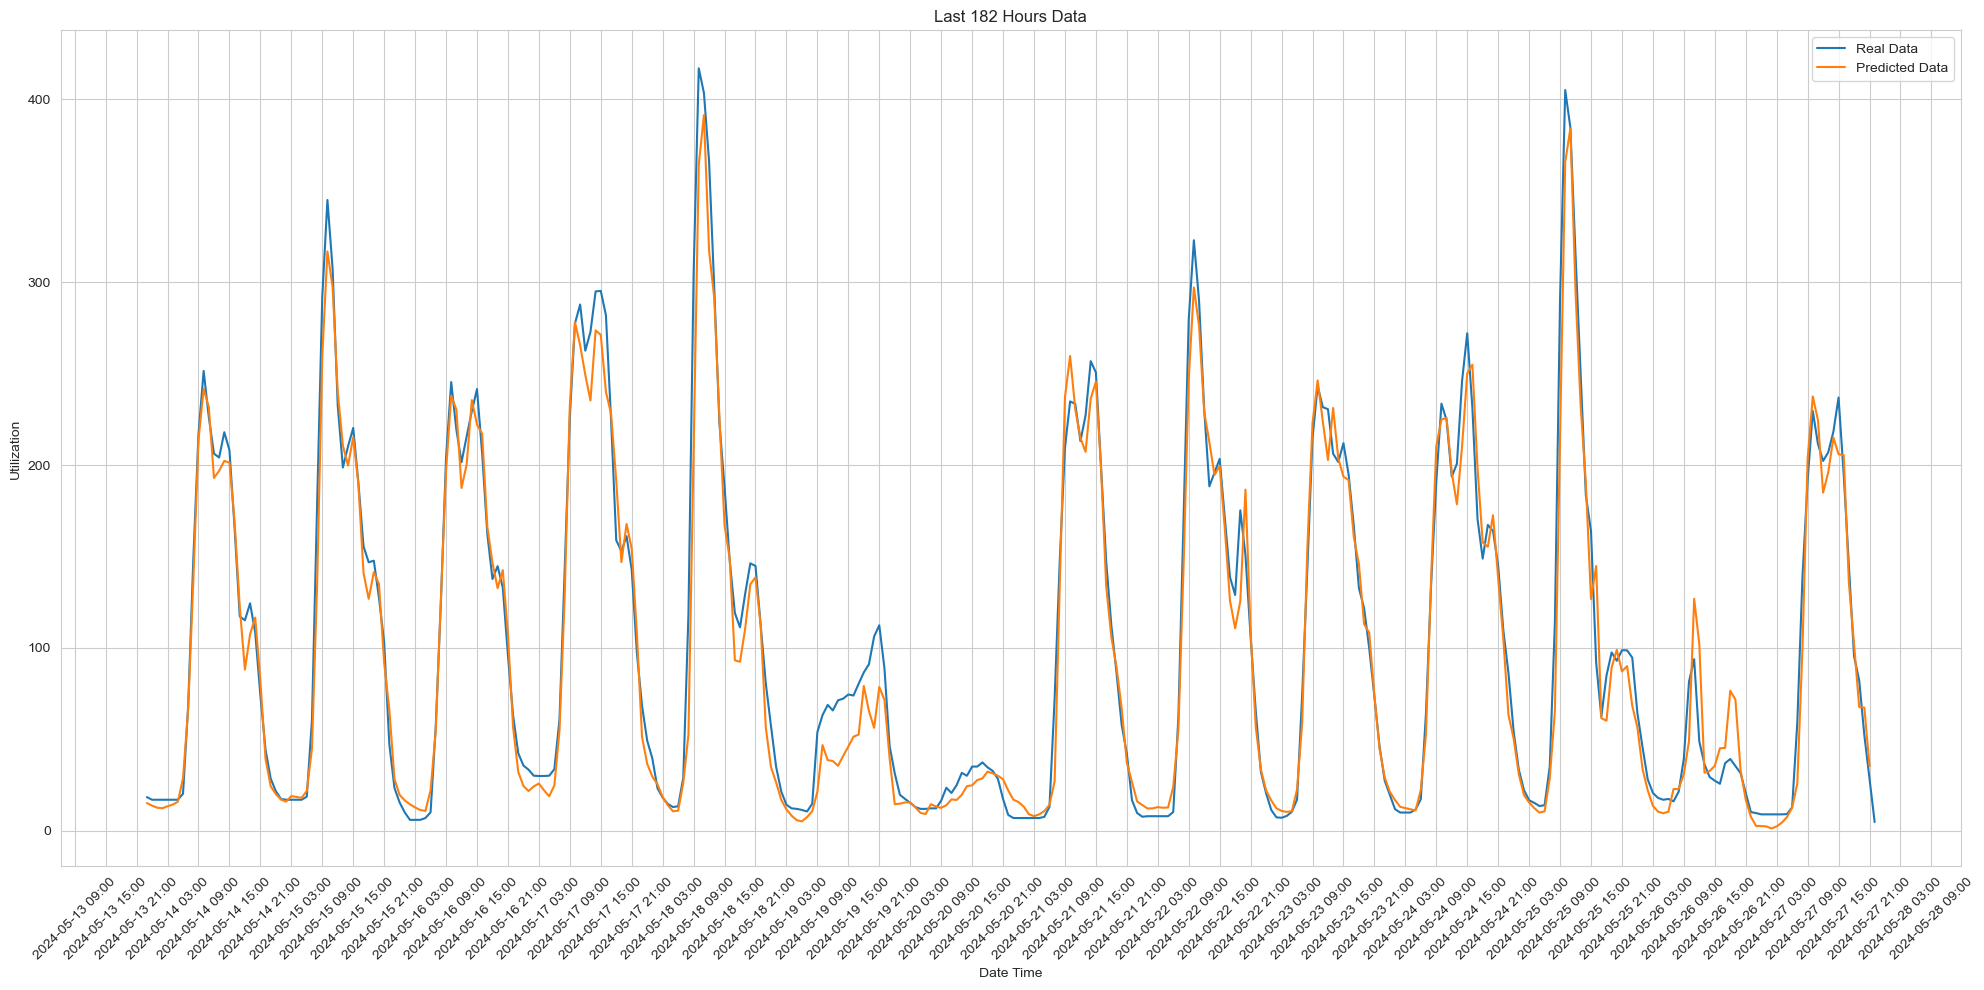

In [13]:

import matplotlib.dates as mdates
last_48 = testPredictPlot[-336:]
last_48 = np.clip(last_48, 0, 429)
last_48_dates = dates[-336:]
last_48_dataset = dataset[-336:, :]

plt.figure(figsize=(20, 10))
plt.plot(last_48_dates, last_48_dataset[:,0], label='Real Data')
plt.plot(last_48_dates, last_48, label='Predicted Data')
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xlabel('Date Time')
plt.ylabel('Utilization')
plt.title('Last 182 Hours Data')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [31]:

import plotly.graph_objects as go

# Create figure
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dates,
        y=dataset[:,0],
        name='True Values',
        line=dict(color='blue')
    )
)

fig.add_trace(
    go.Scatter(
        x=dates,
        y=testPredictPlot,
        name='Predictions',
        line=dict(color='red')
    )
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=trainPredictPlot,
        name='Predictions',
        line=dict(color='green')
    )
)
# Set title
fig.update_layout(
    title_text="Time series with range slider and selectors"
)

# Add range slider
fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    autosize=False,
    width=1400,
    height=800
)
fig.show()


22/22 - 3s - 144ms/step


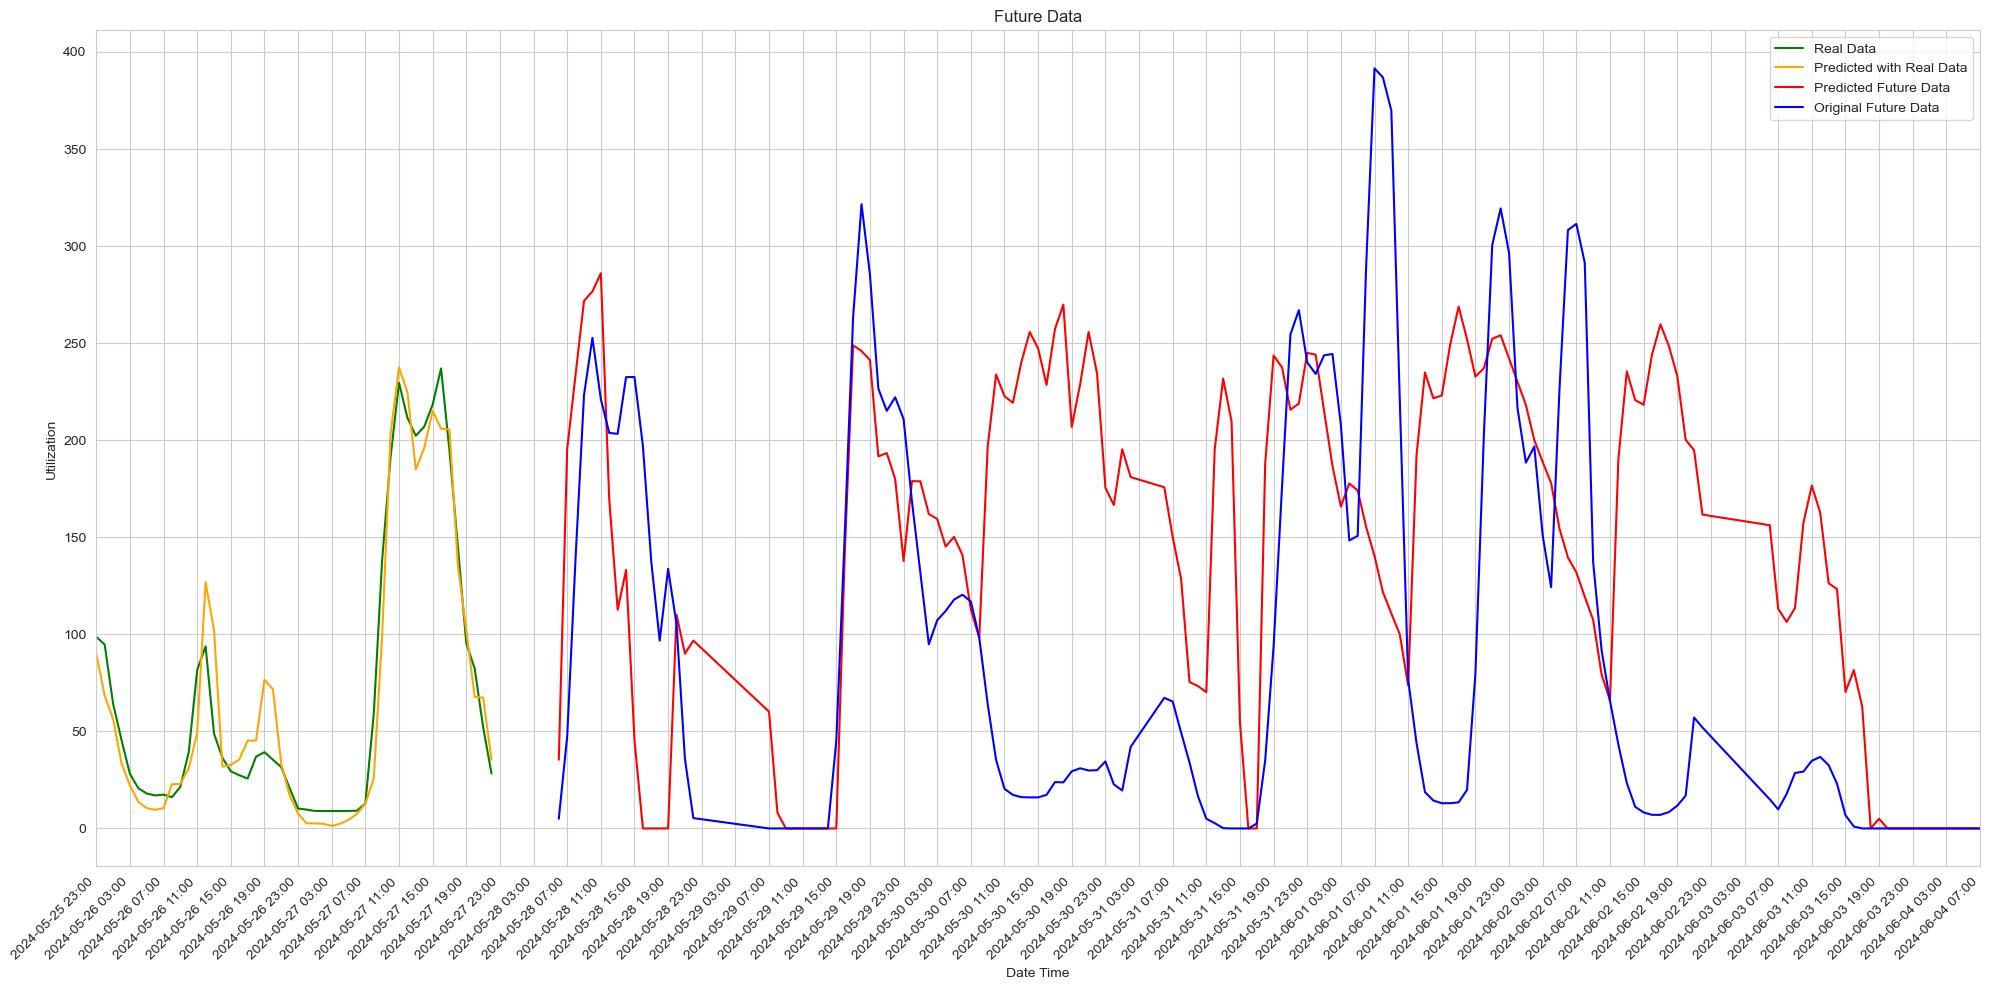

DatetimeIndex(['2024-05-25 23:00:00', '2024-05-26 00:00:00',
               '2024-05-26 01:00:00', '2024-05-26 02:00:00',
               '2024-05-26 03:00:00', '2024-05-26 04:00:00',
               '2024-05-26 05:00:00', '2024-05-26 06:00:00',
               '2024-05-26 07:00:00', '2024-05-26 08:00:00',
               '2024-05-26 09:00:00', '2024-05-26 10:00:00',
               '2024-05-26 11:00:00', '2024-05-26 12:00:00',
               '2024-05-26 13:00:00', '2024-05-26 14:00:00',
               '2024-05-26 15:00:00', '2024-05-26 16:00:00',
               '2024-05-26 17:00:00', '2024-05-26 18:00:00',
               '2024-05-26 19:00:00', '2024-05-26 20:00:00',
               '2024-05-26 21:00:00', '2024-05-26 22:00:00',
               '2024-05-26 23:00:00', '2024-05-27 00:00:00',
               '2024-05-27 01:00:00', '2024-05-27 02:00:00',
               '2024-05-27 03:00:00', '2024-05-27 04:00:00',
               '2024-05-27 05:00:00', '2024-05-27 06:00:00',
               '2024-05-

In [30]:
prediction_dataX, prediction_dataY = create_dataset(test, window)
copy = prediction_dataX.copy()
yhat = model.predict(prediction_dataX, verbose=2)


control_data = pd.DataFrame(data)
control_data['timestamp'] = pd.to_datetime(control_data['timestamp'])
start_date = pd.to_datetime('2024-05-28')
end_date = pd.to_datetime('2024-06-30')
control_data = control_data[(control_data['timestamp'] >= start_date) & (control_data['timestamp'] <= end_date)]
control_data['hour'] = control_data['timestamp'].dt.hour
control_data['dayOfWeek'] = control_data['timestamp'].dt.dayofweek
control_data.set_index('timestamp', inplace=True)
control_dates_index = control_data.index
control_data = control_data.asfreq('H')
mask = (control_data['dayOfWeek'].isna()) | (control_data['dayOfWeek'] == 0)
control_data.loc[mask, 'dayOfWeek'] = control_data.index[mask].dayofweek
control_data['hour'] = control_data['hour'].interpolate(method='time')
control_data.reset_index(inplace=True)
control_data['event_name'] = control_data['event_name'].apply(lambda x: 1 if isinstance(x, str) and x != "0" else 0)
control_data['holiday'] = control_data['holiday'].apply(lambda x: 1 if pd.notna(x) and isinstance(x, str) and x.strip() != "" else 0)
control_data = control_data.fillna(0)


current_seq = prediction_dataX[-1].copy()  # shape: (168, 7)
last_timestamp = start_dataset.index[-1]
future_steps = 144

predicted_values = []

for i in range(future_steps):

    input_seq = np.expand_dims(current_seq, axis=0)
    pred = model.predict(input_seq, verbose=0)
    pred_value = pred.squeeze()  # float

    predicted_values.append(pred_value)
    future_features = control_data.loc[i, ['rhum', 'tsun', 'event_name', 'holiday', 'hour', 'dayOfWeek']]

    hour = future_features['hour']
    day_of_week = future_features['dayOfWeek']

    rhum = future_features['rhum']
    tsun = future_features['tsun']
    event_name = future_features['event_name']
    holiday = future_features['holiday']

    # value + other Features
    next_step = np.array([pred_value, rhum, tsun, event_name, holiday, hour, day_of_week]).reshape(1, 7)

    # move window
    current_seq = np.vstack((current_seq[1:], next_step))

future = scaler.inverse_transform(np.concatenate((yhat, np.ones((len(yhat), 6))), axis=1))[:,0]
tested = scaler.inverse_transform(np.concatenate((prediction_dataY.reshape(-1, 1), np.ones((len(prediction_dataY), 6))), axis=1))[:,0]
final_values = scaler.inverse_transform(np.concatenate(
    (np.array(predicted_values).reshape(-1, 1), np.ones((future_steps, 6))),
    axis=1
))[:, 0]
final_values = np.clip(final_values, 0, 429)

hist_axis = 48
forecast_axis = hist_axis + len(final_values)
last_data = control_data['value'].values[:len(final_values)]
last_dates = dates[-hist_axis:]

all_dates = last_dates.union(control_dates_index[:len(final_values)])


plt.figure(figsize=(20, 10))
# Historie (Real Data)
plt.plot(all_dates[:48], tested[-48:], color='green', label='Real Data')
# Historie (Predicted Data)
plt.plot(all_dates[:48], future[-48:], color='orange', label='Predicted with Real Data')
# Prognose (Other Future Data)
plt.plot(all_dates[48:], final_values.tolist(), color='red', label='Predicted Future Data ')
# Prognose (Original Future Data)
plt.plot(all_dates[48:], last_data.tolist(), color='blue', label='Original Future Data')
plt.xlim(all_dates[0], all_dates[-1])
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
plt.xlabel('Date Time')
plt.ylabel('Utilization')
plt.title('Future Data')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(last_dates)
print(control_dates_index[:len(final_values)])
print(all_dates)